# Laboratorium 11 — minLSTM
 
**Źródło:** Feng et al., *Were RNNs All We Needed?*, arXiv:2410.01201 (2024)  
**Dataset:** IMDB (analiza sentymentu)

# 1. Teoria — minLSTM

## 1.1 Motywacja

Klasyczny LSTM ma dwa fundamentalne ograniczenia:

1. **Sekwencyjne BPTT** — bramki $f_t$, $i_t$, $o_t$ zależą od $h_{t-1}$. Aby policzyć krok $t$, trzeba mieć gotowy krok $t-1$. Dla sekwencji długości $T$ to $T$ sekwencyjnych operacji na GPU — brak możliwości zrównoleglenia.
2. **Duża liczba parametrów** — $O(4 d_h(d_x + d_h))$, gdzie $d_h$ to rozmiar stanu ukrytego, $d_x$ to rozmiar wejścia.

## 1.2 Klasyczny LSTM — przypomnienie

$$f_t = \sigma(\text{Linear}([x_t, h_{t-1}])), \quad i_t = \sigma(\text{Linear}([x_t, h_{t-1}]))$$
$$o_t = \sigma(\text{Linear}([x_t, h_{t-1}])), \quad \tilde{c}_t = \tanh(\text{Linear}([x_t, h_{t-1}]))$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t, \quad h_t = o_t \odot \tanh(c_t)$$

Zależność od $h_{t-1}$ we wszystkich bramkach uniemożliwia zrównoleglenie.

## 1.3 Trzy kroki uproszczenia → minLSTM

**Krok 1 — usunięcie zależności od $h_{t-1}$ z bramek:**

$$f_t = \sigma(\text{Linear}(x_t)), \quad i_t = \sigma(\text{Linear}(x_t)), \quad \tilde{h}_t = \text{Linear}(x_t)$$

Teraz $f_t$, $i_t$, $\tilde{h}_t$ są znane z góry dla całej sekwencji — można zastosować parallel scan.

**Krok 2 — usunięcie `tanh`:**  
`tanh` stabilizował gradienty przy mnożeniu przez $h_{t-1}$. Po kroku 1 ta zależność znikła — `tanh` jest zbędny.

**Krok 3 — normalizacja bramek (time-independence):**  
W LSTM $f_t$ i $i_t$ są niezależne — obie mogą być bliskie 1, co powoduje że $c_t$ rośnie z $T$. Wymuszamy $f'_t + i'_t = 1$:

$$f'_t = \frac{f_t}{f_t + i_t}, \quad i'_t = \frac{i_t}{f_t + i_t}$$

$h_t$ staje się ważoną średnią — skala nie rośnie z $T$. Efekt uboczny: bramka $o_t$ i stan $c_t$ stają się zbędne.

## 1.4 Finalna postać minLSTM

$$\boxed{h_t = f'_t \odot h_{t-1} + i'_t \odot \tilde{h}_t}$$

gdzie: $f_t = \sigma(\text{Linear}(x_t))$, $i_t = \sigma(\text{Linear}(x_t))$, $\tilde{h}_t = \text{Linear}(x_t)$, $f'_t = f_t/(f_t+i_t)$, $i'_t = i_t/(f_t+i_t)$.

Parametry: $O(3 d_h d_x)$ — przy $d_h = 2d_x$ to **~25% parametrów LSTM**.

## 1.5 Parallel Scan — dlaczego można zrównoleglić

Rekurencja minLSTM ma postać $h_t = a_t \odot h_{t-1} + b_t$, gdzie $a_t = f'_t$ i $b_t = i'_t \odot \tilde{h}_t$.  
Ponieważ $a_t$ i $b_t$ zależą tylko od $x_t$ (nie od $h_{t-1}$), można rozwinąć całą rekurencję algebraicznie i obliczyć $h_{1:T}$ równolegle przez algorytm prefix scan.

Implementacja w przestrzeni logarytmicznej zapobiega numerical underflow przy mnożeniu wielu $f'_t \in (0,1)$:

$$\log(f'_1 \cdot f'_2 \cdots f'_t) = \sum_{k=1}^t \log f'_k \quad \rightarrow \quad \texttt{torch.cumsum}(\log f'_t)$$

**Przyspieszenie w praktyce** (T4 GPU, batch=64): $T=512$: **235×**, $T=4096$: **1361×** względem klasycznego LSTM.

## 1.6 Uwaga: minimalna liczba warstw

Przy **1 warstwie** bramki zależą od $x_t$ — stałego embeddingu tokenu. Bramki są time-independent: model nie potrafi selektywnie filtrować na podstawie kontekstu. Od **2 warstw** wejściem jest $h^{(1)}_t$ zawierający skompresowaną historię — bramki stają się context-aware.

Potwierdzone eksperymentalnie: 1 warstwa → 37% accuracy, 2 warstwy → 86%, 3 warstwy → 96% (Selective Copying Task).

# 2. Wczytanie danych

Wczytujemy IMDB w trzech wariantach długości sekwencji (`maxlen`), aby zbadać czy przewaga minLSTM rośnie wraz z długością wejścia. Używamy wariantu **padded** — minLSTM wymaga regularnego tensora `[B, T, F]`, a padding jest obsługiwany przez indeksowanie `lengths`.

In [1]:
from tensorflow.keras.datasets import imdb

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import time
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_WORDS = 10000
VOCAB_SIZE = NUM_WORDS + 3  # +3 bo index_from=3
BATCH     = 64
HIDDEN    = 128
LAYERS    = 3
LR        = 1e-3
EPOCHS    = 10

MAXLENS = [128, 512, 1024]

print(f'Device: {DEVICE}')

Device: cuda


In [2]:
class IMDBDataset(Dataset):
    def __init__(self, x, y):
        self.x = [torch.tensor(seq, dtype=torch.long) for seq in x]
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


def collate_padded(batch):
    """Zwraca (padded [B,T], lengths [B], labels [B])."""
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in sequences])
    padded  = pad_sequence(sequences, batch_first=True, padding_value=0)
    return padded, lengths, torch.stack(labels)


def get_imdb_dataloaders(maxlen, batch_size=BATCH):
    """Zwraca (train_loader, test_loader) dla danego maxlen."""
    (x_train, y_train), (x_test, y_test) = imdb.load_data(
        path='imdb.npz', num_words=NUM_WORDS, maxlen=maxlen,
        seed=113, start_char=1, oov_char=2, index_from=3
    )
    train_ds = IMDBDataset(x_train, y_train)
    test_ds  = IMDBDataset(x_test,  y_test)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  collate_fn=collate_padded)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, collate_fn=collate_padded)
    return train_loader, test_loader


data = {}
for maxlen in MAXLENS:
    data[maxlen] = get_imdb_dataloaders(maxlen)
    print(f'maxlen={str(maxlen):4s} — train batches: {len(data[maxlen][0])}, test batches: {len(data[maxlen][1])}')

maxlen=128  — train batches: 92, test batches: 98
maxlen=512  — train batches: 360, test batches: 363
maxlen=1024 — train batches: 390, test batches: 391


# 3. Modele

## 3.1 Baseline — LSTM z listy 9

In [3]:
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

class LSTMNet(nn.Module):
    """LSTM z nn.LSTM/cuDNN — baseline z listy 9."""

    def __init__(self, input_size, hidden_size, num_layers, num_classes,
                 bidirectional=False):
        super().__init__()
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            bidirectional=bidirectional,
            batch_first=True,
        )
        fc_in = hidden_size * (2 if bidirectional else 1)
        self.fc = nn.Linear(fc_in, num_classes)

    def forward(self, x, lengths):
        B = x.size(0)
        embedded = self.embedding(x)   # [B, T, H]

        # pack_padded_sequence żeby LSTM nie marnował czasu na padding
        packed   = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out_pack, _ = self.lstm(packed)
        out, _   = pad_packed_sequence(out_pack, batch_first=True)  # [B, T_max, H]

        idx = (lengths - 1).clamp(min=0).to(x.device)

        if self.bidirectional:
            H   = out.size(2) // 2
            fwd = out[torch.arange(B, device=x.device), idx, :H]
            bwd = out[:, 0, H:]
            last = torch.cat([fwd, bwd], dim=-1)
        else:
            last = out[torch.arange(B, device=x.device), idx]

        return self.fc(last)

## 3.2 Modyfikacja — minLSTM


In [4]:
def g(x):
    """
    Funkcja zachowująca dodatniość — Appendix B (Feng et al., 2024).
    g(x) = x + 0.5     dla x >= 0
    g(x) = sigmoid(x)  dla x < 0
    Zawsze g(x) > 0, więc można wziąć logarytm.
    """
    return torch.where(x >= 0, x + 0.5, torch.sigmoid(x))


def log_g(x):
    """
    Numerycznie stabilne log(g(x)) — Appendix B (Feng et al., 2024).

    log_g(x) = log(x + 0.5)   dla x >= 0
    log_g(x) = -softplus(-x)  dla x < 0   (= log(sigmoid(x)))

    UWAGA: torch.where liczy OBIE gałęzie, więc musimy zabezpieczyć
    wejście do log() przez clamp, inaczej log(ujemne)=NaN propaguje się
    przez gradient nawet jeśli where wybierze drugą gałąź.
    """
    safe_pos = torch.clamp(x + 0.5, min=1e-7)   # bezpieczne dla x < -0.5
    return torch.where(x >= 0, torch.log(safe_pos), -F.softplus(-x))


def parallel_scan_log(log_coeffs, log_values):
    """
    Log-space parallel scan — Appendix B, Listing 5 (Feng et al., 2024).
    Rozwiązuje h_t = a_t * h_{t-1} + b_t równolegle.

    Args:
        log_coeffs: log(a_t),                  shape [B, T, D]
        log_values: log([h_0, b_1, ..., b_T]), shape [B, T+1, D]
    Returns:
        h_1:T, shape [B, T, D]
    """
    a_star = F.pad(torch.cumsum(log_coeffs, dim=1), (0, 0, 1, 0))
    log_h0_plus_b_star = torch.logcumsumexp(log_values - a_star, dim=1)
    log_h = a_star + log_h0_plus_b_star
    return torch.exp(log_h)[:, 1:]


class MinLSTMLayer(nn.Module):
    """
    Jedna warstwa minLSTM — parallel mode (log-space).
    Implementacja zgodna z Appendix B papera (Feng et al., arXiv:2410.01201).
    """

    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.linear_f = nn.Linear(input_size, hidden_size)
        self.linear_i = nn.Linear(input_size, hidden_size)
        self.linear_h = nn.Linear(input_size, hidden_size)

    def forward(self, x, h_0=None):
        # x: [B, T, input_size]
        B, T, _ = x.shape
        if h_0 is None:
            h_0 = torch.zeros(B, 1, self.hidden_size, device=x.device)

        # pre-aktywacje bramek
        k_f = self.linear_f(x)        # [B, T, H]
        k_i = self.linear_i(x)        # [B, T, H]
        h_tilde = self.linear_h(x)    # [B, T, H]

        # normalizacja w log-space: f' = f/(f+i), i' = i/(f+i)
        # log(f) = log(sigmoid(k_f)) = -softplus(-k_f)
        # log(f+i) liczymy przez logaddexp dla stabilności
        log_f = -F.softplus(-k_f)     # log(sigmoid(k_f))
        log_i = -F.softplus(-k_i)     # log(sigmoid(k_i))
        log_denom   = torch.logaddexp(log_f, log_i)   # log(f + i)
        log_f_prime = log_f - log_denom               # log(f')
        log_i_prime = log_i - log_denom               # log(i')

        # b_t = i'_t * g(h̃_t)  →  log(b_t) = log(i'_t) + log_g(h̃_t)
        log_b = log_i_prime + log_g(h_tilde)          # [B, T, H]

        # h_0 przepuszczony przez g (stan początkowy w tej samej przestrzeni)
        log_h0 = log_g(h_0)                           # [B, 1, H]

        log_values = torch.cat([log_h0, log_b], dim=1)  # [B, T+1, H]
        h = parallel_scan_log(log_f_prime, log_values)   # [B, T, H]
        return h


class MinLSTMNet(nn.Module):
    """Wielowarstwowa sieć minLSTM do klasyfikacji sekwencji."""

    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.layers = nn.ModuleList([
            MinLSTMLayer(hidden_size, hidden_size)
            for _ in range(num_layers)
        ])
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, lengths):
        h = self.embedding(x)          # [B, T, H]
        for layer in self.layers:
            h = layer(h)               # [B, T, H]
        idx    = (lengths - 1).clamp(min=0).to(x.device)
        last_h = h[torch.arange(h.size(0), device=x.device), idx]
        return self.fc(last_h)


# ── Sekwencyjny LSTM w czystym PyTorch — fair comparison z papera ─────────────

class LSTMManualNet(nn.Module):
    """
    LSTM zaimplementowany pętlą for — bez nn.LSTM/cuDNN.
    Fair comparison z papera: minLSTM vs LSTM na równych warunkach
    (obie implementacje w czystym PyTorch, bez dedykowanych CUDA kerneli).
    """

    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.embedding   = nn.Embedding(input_size, hidden_size)
        self.Wx = nn.ModuleList([
            nn.Linear(hidden_size, 4 * hidden_size) for _ in range(num_layers)
        ])
        self.Wh = nn.ModuleList([
            nn.Linear(hidden_size, 4 * hidden_size, bias=False) for _ in range(num_layers)
        ])
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, lengths):
        B, T = x.shape
        h = self.embedding(x)   # [B, T, H]

        for l in range(self.num_layers):
            hh = torch.zeros(B, self.hidden_size, device=x.device)
            cc = torch.zeros(B, self.hidden_size, device=x.device)
            out = []
            for t in range(T):
                gates = self.Wx[l](h[:, t, :]) + self.Wh[l](hh)
                f, i, gg, o = gates.chunk(4, dim=-1)
                cc = torch.sigmoid(f) * cc + torch.sigmoid(i) * torch.tanh(gg)
                hh = torch.sigmoid(o) * torch.tanh(cc)
                out.append(hh.unsqueeze(1))
            h = torch.cat(out, dim=1)   # [B, T, H]

        idx    = (lengths - 1).clamp(min=0).to(x.device)
        last_h = h[torch.arange(B, device=x.device), idx]
        return self.fc(last_h)

In [5]:
# ── Porównanie liczby parametrów ──────────────────────────────────────────────

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def count_params_breakdown(model):
    total = count_params(model)
    embed = sum(p.numel() for p in model.embedding.parameters())
    fc    = sum(p.numel() for p in model.fc.parameters())
    recur = total - embed - fc
    return total, embed, recur, fc

models_to_compare = [
    ('LSTM (nn.LSTM)',  LSTMNet(VOCAB_SIZE, HIDDEN, 1, 2)),
    ('BiLSTM',         LSTMNet(VOCAB_SIZE, HIDDEN, 1, 2, bidirectional=True)),
    ('LSTM manual',    LSTMManualNet(VOCAB_SIZE, HIDDEN, 1, 2)),
    ('minLSTM',        MinLSTMNet(VOCAB_SIZE, HIDDEN, 1, 2)),
]

base_recur = count_params_breakdown(models_to_compare[0][1])[2]

print(f"{'Model':<18} {'Łącznie':>10} {'Embedding':>10} {'Rekurencja':>12} {'FC':>8} {'Rekur. vs LSTM':>16}")
print("-" * 78)
for name, m in models_to_compare:
    total, embed, recur, fc = count_params_breakdown(m)
    print(f"{name:<18} {total:>10,} {embed:>10,} {recur:>12,} {fc:>8,} {recur/base_recur*100:>14.1f}%")

# Wartości teoretyczne z papera
dh = HIDDEN
print(f"\nTeoretyczne (1 warstwa, dx=dh={dh}, bez embedding/FC):")
print(f"  LSTM:    4*dh*(dx+dh) = {4*dh*2*dh:,}")
print(f"  minLSTM: 3*dh*dx      = {3*dh*dh:,}  ({3*dh*dh/(4*dh*2*dh)*100:.1f}% LSTM)")


Model                 Łącznie  Embedding   Rekurencja       FC   Rekur. vs LSTM
------------------------------------------------------------------------------
LSTM (nn.LSTM)      1,412,738  1,280,384      132,096      258          100.0%
BiLSTM              1,545,090  1,280,384      264,192      514          200.0%
LSTM manual         1,412,226  1,280,384      131,584      258           99.6%
minLSTM             1,330,178  1,280,384       49,536      258           37.5%

Teoretyczne (1 warstwa, dx=dh=128, bez embedding/FC):
  LSTM:    4*dh*(dx+dh) = 131,072
  minLSTM: 3*dh*dx      = 49,152  (37.5% LSTM)


# 4. Pętla treningowa

In [6]:
def validate(model, loss_fn, dataloader, num_classes, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    tps = torch.zeros(num_classes, device=device)
    fps = torch.zeros(num_classes, device=device)
    fns = torch.zeros(num_classes, device=device)

    with torch.no_grad():
        for x, lengths, y in dataloader:
            x, y = x.to(device), y.to(device)
            out  = model(x, lengths)
            total_loss += loss_fn(out, y).item()
            preds = torch.argmax(out, dim=1)
            correct += (preds == y).sum().item()
            total   += y.size(0)
            for c in range(num_classes):
                tps[c] += ((preds == c) & (y == c)).sum()
                fps[c] += ((preds == c) & (y != c)).sum()
                fns[c] += ((preds != c) & (y == c)).sum()

    acc = correct / total
    precisions = tps / (tps + fps + 1e-8)
    recalls    = tps / (tps + fns + 1e-8)
    macro_f1   = (2 * precisions * recalls / (precisions + recalls + 1e-8)).mean().item()
    return total_loss / len(dataloader), acc, macro_f1


def fit(model, optimiser, loss_fn, train_dl, val_dl, epochs, num_classes, device):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for x, lengths, y in train_dl:
            x, y = x.to(device), y.to(device)
            optimiser.zero_grad()
            out  = model(x, lengths)
            loss = loss_fn(out, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimiser.step()
            train_loss    += loss.item()
            train_correct += (torch.argmax(out, dim=1) == y).sum().item()
            train_total   += y.size(0)

        train_loss /= len(train_dl)
        train_acc   = train_correct / train_total
        val_loss, val_acc, val_f1 = validate(model, loss_fn, val_dl, num_classes, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        print(f"  Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f}")
    return history


def run_experiment(label, model, train_dl, val_dl, epochs, num_classes, device, lr=LR):
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    model = model.to(device)
    optimiser = optim.Adam(model.parameters(), lr=lr)
    loss_fn   = nn.CrossEntropyLoss()

    t0 = time.time()
    history = fit(model, optimiser, loss_fn, train_dl, val_dl, epochs, num_classes, device)
    elapsed = time.time() - t0

    best_acc = max(history['val_acc'])
    best_f1  = max(history['val_f1'])
    print(f"  → Czas: {elapsed:.1f}s | Best Acc: {best_acc:.4f} | Best F1: {best_f1:.4f}")

    return {
        'label':    label,
        'history':  history,
        'best_acc': best_acc,
        'best_f1':  best_f1,
        'time_s':   elapsed,
        'model':    model,
    }

# 5. Funkcje wizualizacji

In [7]:
def plot_history(results, title):
    """Krzywe uczenia dla listy wyników z run_experiment."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title)
    linestyles = ['-', '--', ':', '-.']
    for (res, ls) in zip(results, linestyles):
        h = res['history']
        axes[0].plot(h['val_loss'], ls=ls, label=res['label'])
        axes[1].plot(h['val_acc'],  ls=ls, label=res['label'])
    axes[0].set_title('Val Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[1].set_title('Val Acc');  axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout()
    plt.show()


def print_summary(results):
    """Tabela podsumowująca wyniki wszystkich eksperymentów."""
    print(f"\n{'Model':<35} {'Best Acc':>10} {'Best F1':>10} {'Czas (s)':>10}")
    print("-" * 67)
    for res in results:
        print(f"{res['label']:<35} {res['best_acc']:>10.4f} "
              f"{res['best_f1']:>10.4f} {res['time_s']:>10.1f}")


def plot_time_vs_maxlen(results_by_maxlen):
    """
    Wykres czasu trenowania w funkcji długości sekwencji.

    results_by_maxlen: dict {maxlen: {label: result}}
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle('Wpływ długości sekwencji na czas trenowania i accuracy')

    # zbieramy unikalne etykiety
    labels = list(next(iter(results_by_maxlen.values())).keys())
    maxlens = sorted(results_by_maxlen.keys())
    linestyles = ['-', '--', ':', '-.']

    for label, ls in zip(labels, linestyles):
        times  = [results_by_maxlen[ml][label]['time_s']   for ml in maxlens]
        accs   = [results_by_maxlen[ml][label]['best_acc'] for ml in maxlens]
        axes[0].plot(maxlens, times, ls=ls, marker='o', label=label)
        axes[1].plot(maxlens, accs,  ls=ls, marker='o', label=label)

    axes[0].set_title('Czas trenowania [s]');  axes[0].set_xlabel('maxlen'); axes[0].legend()
    axes[1].set_title('Best Val Accuracy');    axes[1].set_xlabel('maxlen'); axes[1].legend()
    plt.tight_layout()
    plt.show()

# 6. Eksperymenty — porównanie modeli

Dla każdego `maxlen` porównujemy cztery warianty, wszystkie z `LAYERS=3`:
- **LSTM** — `nn.LSTM` z cuDNN, bierze ostatni prawdziwy token przez `lengths`
- **BiLSTM** — bidirectional `nn.LSTM`
- **LSTM manual** — LSTM pętlą `for` w czystym PyTorch (fair comparison z papera)
- **minLSTM** — modyfikacja z parallel scan (czysty PyTorch)

`LSTM manual` vs `minLSTM` to bezpośrednie porównanie z papera — obie implementacje w czystym PyTorch.

In [37]:
results = {}  # klucz: (maxlen, wariant)

for maxlen in MAXLENS:
    train_dl, test_dl = data[maxlen]

    print(f"\n{'#'*60}")
    print(f"# maxlen={maxlen}  |  warstwy={LAYERS}  |  epoki={EPOCHS}")
    print(f"{'#'*60}")

    res = run_experiment(
        'LSTM',
        LSTMNet(VOCAB_SIZE, HIDDEN, LAYERS, 2, bidirectional=False),
        train_dl, test_dl, EPOCHS, 2, DEVICE
    )
    results[(maxlen, 'LSTM')] = res

    res = run_experiment(
        'BiLSTM',
        LSTMNet(VOCAB_SIZE, HIDDEN, LAYERS, 2, bidirectional=True),
        train_dl, test_dl, EPOCHS, 2, DEVICE
    )
    results[(maxlen, 'BiLSTM')] = res

    res = run_experiment(
        'LSTM manual',
        LSTMManualNet(VOCAB_SIZE, HIDDEN, LAYERS, 2),
        train_dl, test_dl, EPOCHS, 2, DEVICE
    )
    results[(maxlen, 'LSTM manual')] = res

    res = run_experiment(
        'minLSTM',
        MinLSTMNet(VOCAB_SIZE, HIDDEN, LAYERS, 2),
        train_dl, test_dl, EPOCHS, 2, DEVICE
    )
    results[(maxlen, 'minLSTM')] = res


############################################################
# maxlen=128  |  warstwy=3  |  epoki=10
############################################################

  LSTM
  Epoch 1/10 | Train Loss: 0.6393 Acc: 0.6306 | Val Loss: 0.5896 Acc: 0.6922 F1: 0.6922
  Epoch 2/10 | Train Loss: 0.5068 Acc: 0.7499 | Val Loss: 0.5885 Acc: 0.7384 F1: 0.7238
  Epoch 3/10 | Train Loss: 0.3836 Acc: 0.8334 | Val Loss: 0.5020 Acc: 0.7852 F1: 0.7822
  Epoch 4/10 | Train Loss: 0.2852 Acc: 0.8863 | Val Loss: 0.4500 Acc: 0.8041 F1: 0.8029
  Epoch 5/10 | Train Loss: 0.2153 Acc: 0.9189 | Val Loss: 0.5230 Acc: 0.7988 F1: 0.7987
  Epoch 6/10 | Train Loss: 0.1515 Acc: 0.9460 | Val Loss: 0.5716 Acc: 0.8115 F1: 0.8086
  Epoch 7/10 | Train Loss: 0.0965 Acc: 0.9647 | Val Loss: 0.5777 Acc: 0.8179 F1: 0.8173
  Epoch 8/10 | Train Loss: 0.0597 Acc: 0.9817 | Val Loss: 0.7107 Acc: 0.7934 F1: 0.7933
  Epoch 9/10 | Train Loss: 0.0381 Acc: 0.9877 | Val Loss: 1.0127 Acc: 0.8158 F1: 0.8126
  Epoch 10/10 | Train Loss: 0.0292 Ac

# 7. Analiza wyników

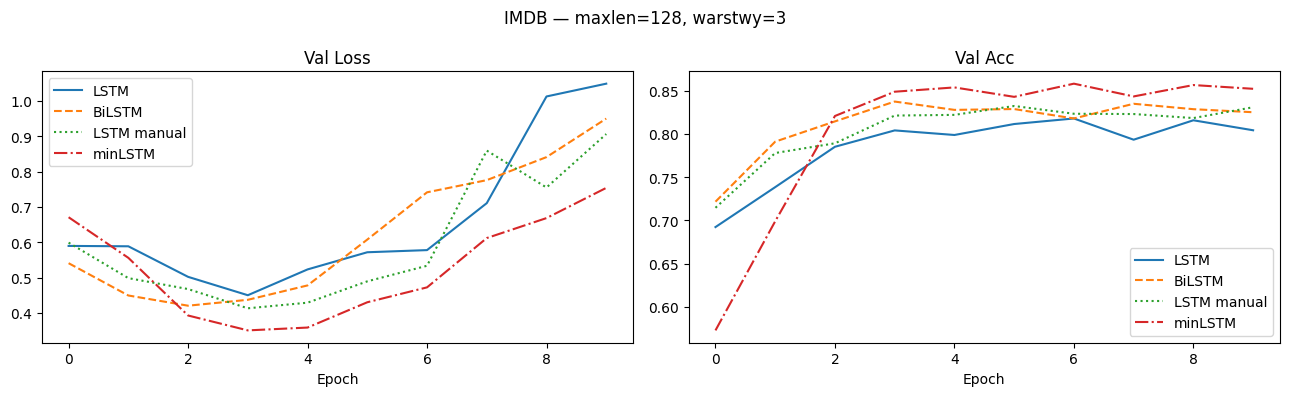

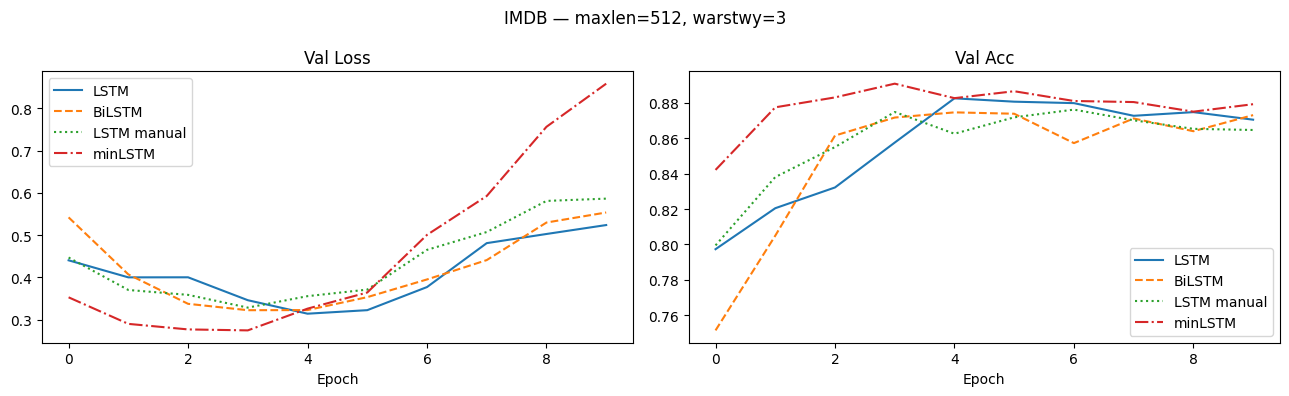

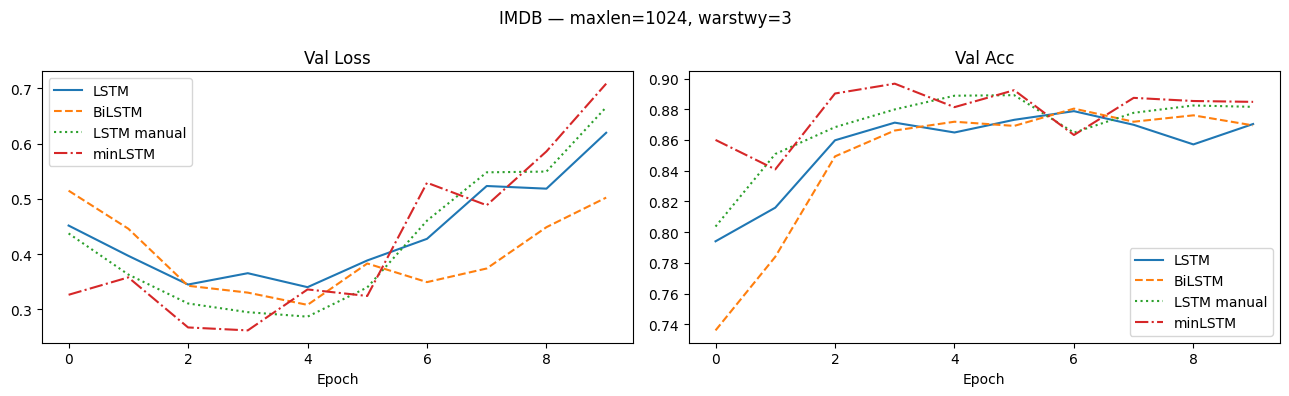


Wariant           maxlen   Best Acc    Best F1   Czas (s)
-------------------------------------------------------
LSTM                 128     0.8179     0.8173       57.1
BiLSTM               128     0.8375     0.8366      105.0
LSTM manual          128     0.8324     0.8319      525.9
minLSTM              128     0.8582     0.8577       24.0

LSTM                 512     0.8826     0.8826      540.9
BiLSTM               512     0.8747     0.8747     1090.9
LSTM manual          512     0.8762     0.8762     7090.1
minLSTM              512     0.8909     0.8908      206.5

LSTM                1024     0.8788     0.8787     1013.2
BiLSTM              1024     0.8804     0.8804     2028.7
LSTM manual         1024     0.8892     0.8892    15004.7
minLSTM             1024     0.8966     0.8966      374.9



In [38]:
VARIANTS = ['LSTM', 'BiLSTM', 'LSTM manual', 'minLSTM']

for maxlen in MAXLENS:
    plot_history(
        [results[(maxlen, v)] for v in VARIANTS],
        f'IMDB — maxlen={maxlen}, warstwy={LAYERS}'
    )

print(f"\n{'Wariant':<15} {'maxlen':>8} {'Best Acc':>10} {'Best F1':>10} {'Czas (s)':>10}")
print("-" * 55)
for maxlen in MAXLENS:
    for variant in VARIANTS:
        res = results[(maxlen, variant)]
        print(f"{variant:<15} {str(maxlen):>8} "
              f"{res['best_acc']:>10.4f} {res['best_f1']:>10.4f} {res['time_s']:>10.1f}")
    print()

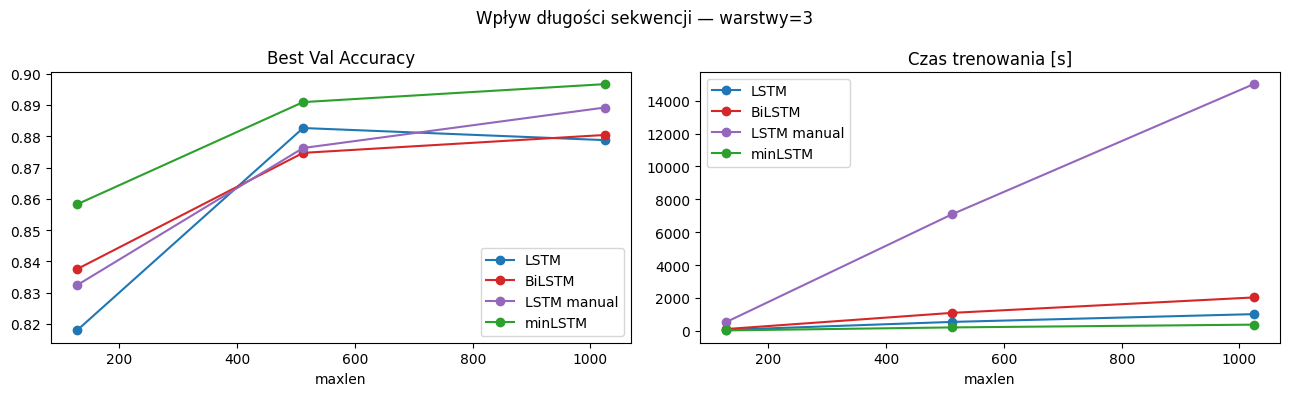


  maxlen  LSTM manual [s]   minLSTM [s]   Speedup
--------------------------------------------------
     128            525.9          24.0     21.9×
     512           7090.1         206.5     34.3×
    1024          15004.7         374.9     40.0×


In [39]:
colors = {'LSTM': 'tab:blue', 'BiLSTM': 'tab:red',
          'LSTM manual': 'tab:purple', 'minLSTM': 'tab:green'}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Wpływ długości sekwencji — warstwy={LAYERS}')
for variant, color in colors.items():
    accs  = [results[(ml, variant)]['best_acc'] for ml in MAXLENS]
    times = [results[(ml, variant)]['time_s']   for ml in MAXLENS]
    axes[0].plot(MAXLENS, accs,  marker='o', color=color, label=variant)
    axes[1].plot(MAXLENS, times, marker='o', color=color, label=variant)
axes[0].set_title('Best Val Accuracy'); axes[0].set_xlabel('maxlen'); axes[0].legend()
axes[1].set_title('Czas trenowania [s]'); axes[1].set_xlabel('maxlen'); axes[1].legend()
plt.tight_layout()
plt.show()

# ── Speedup: LSTM manual vs minLSTM ───────────────────────────────────────────
print(f"\n{'maxlen':>8} {'LSTM manual [s]':>16} {'minLSTM [s]':>13} {'Speedup':>9}")
print("-" * 50)
for maxlen in MAXLENS:
    t_lstm = results[(maxlen, 'LSTM manual')]['time_s']
    t_min  = results[(maxlen, 'minLSTM')]['time_s']
    print(f"{maxlen:>8} {t_lstm:>16.1f} {t_min:>13.1f} {t_lstm/t_min:>8.1f}×")

# 8. Badanie wpływu liczby warstw — minLSTM

Paper wskazuje że przy 1 warstwie bramki minLSTM są time-independent (zależą tylko od embeddingu tokenu, nie od kontekstu), co drastycznie ogranicza ekspresywność. Od 2 warstw bramki widzą time-dependent wejście $h^{(1)}_t$ i model odzyskuje zdolność do kontekstowego filtrowania.

Badamy warstwy 1, 2, 3, 4 dla minLSTM przy `maxlen=None` i `EPOCHS=10`.

In [8]:
LAYERS_TO_TEST = [1, 2, 3, 4]
MAXLEN_LAYERS  = None

train_pad_l, test_pad_l = get_imdb_dataloaders(MAXLEN_LAYERS)

results_layers = {}

for n_layers in LAYERS_TO_TEST:
    res = run_experiment(
        f'minLSTM  L={n_layers}',
        MinLSTMNet(VOCAB_SIZE, HIDDEN, n_layers, 2),
        train_pad_l, test_pad_l, EPOCHS, 2, DEVICE
    )
    results_layers[n_layers] = res


  minLSTM  L=1
  Epoch 1/10 | Train Loss: 0.6442 Acc: 0.6062 | Val Loss: 0.6096 Acc: 0.6480 F1: 0.6470
  Epoch 2/10 | Train Loss: 0.5687 Acc: 0.6886 | Val Loss: 0.5816 Acc: 0.6802 F1: 0.6796
  Epoch 3/10 | Train Loss: 0.5095 Acc: 0.7388 | Val Loss: 0.5652 Acc: 0.6981 F1: 0.6977
  Epoch 4/10 | Train Loss: 0.4505 Acc: 0.7833 | Val Loss: 0.5630 Acc: 0.7152 F1: 0.7145
  Epoch 5/10 | Train Loss: 0.3897 Acc: 0.8225 | Val Loss: 0.5634 Acc: 0.7297 F1: 0.7291
  Epoch 6/10 | Train Loss: 0.3278 Acc: 0.8565 | Val Loss: 0.5700 Acc: 0.7392 F1: 0.7391
  Epoch 7/10 | Train Loss: 0.2647 Acc: 0.8905 | Val Loss: 0.5885 Acc: 0.7502 F1: 0.7502
  Epoch 8/10 | Train Loss: 0.2041 Acc: 0.9214 | Val Loss: 0.6312 Acc: 0.7544 F1: 0.7544
  Epoch 9/10 | Train Loss: 0.1485 Acc: 0.9479 | Val Loss: 0.6800 Acc: 0.7623 F1: 0.7623
  Epoch 10/10 | Train Loss: 0.1020 Acc: 0.9678 | Val Loss: 0.7548 Acc: 0.7615 F1: 0.7615
  → Czas: 143.8s | Best Acc: 0.7623 | Best F1: 0.7623

  minLSTM  L=2
  Epoch 1/10 | Train Loss: 0.5688

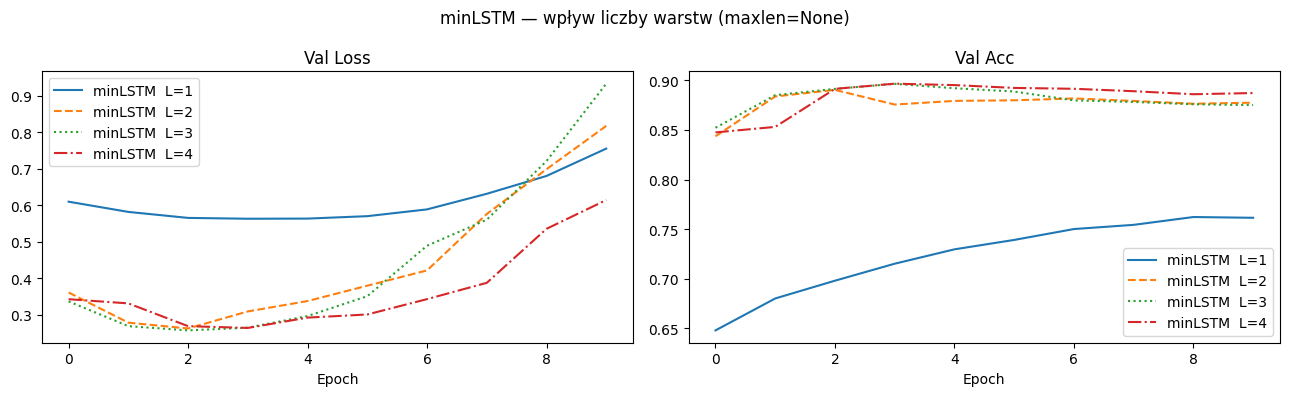


 Warstwy   Best Acc    Best F1   Czas (s)
------------------------------------------
       1     0.7623     0.7623      143.8
       2     0.8904     0.8903      267.6
       3     0.8965     0.8965      385.2
       4     0.8967     0.8967      512.7


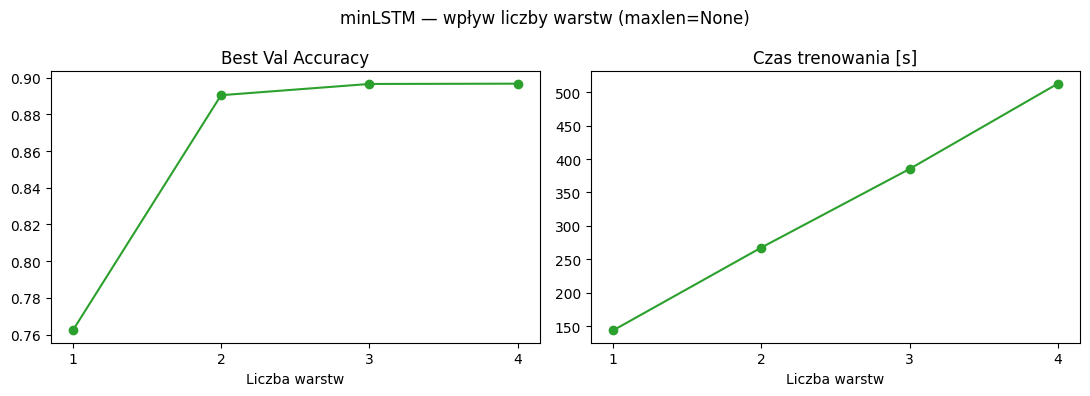

In [9]:
# ── Krzywe uczenia dla każdej liczby warstw ───────────────────────────────────
plot_history(
    [results_layers[n] for n in LAYERS_TO_TEST],
    f'minLSTM — wpływ liczby warstw (maxlen={MAXLEN_LAYERS})'
)

# ── Tabela i wykres accuracy/czas vs liczba warstw ────────────────────────────
print(f"\n{'Warstwy':>8} {'Best Acc':>10} {'Best F1':>10} {'Czas (s)':>10}")
print("-" * 42)
for n in LAYERS_TO_TEST:
    res = results_layers[n]
    print(f"{n:>8} {res['best_acc']:>10.4f} {res['best_f1']:>10.4f} {res['time_s']:>10.1f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle(f'minLSTM — wpływ liczby warstw (maxlen={MAXLEN_LAYERS})')
accs  = [results_layers[n]['best_acc'] for n in LAYERS_TO_TEST]
times = [results_layers[n]['time_s']   for n in LAYERS_TO_TEST]
axes[0].plot(LAYERS_TO_TEST, accs,  marker='o', color='tab:green')
axes[0].set_title('Best Val Accuracy'); axes[0].set_xlabel('Liczba warstw')
axes[0].set_xticks(LAYERS_TO_TEST)
axes[1].plot(LAYERS_TO_TEST, times, marker='o', color='tab:green')
axes[1].set_title('Czas trenowania [s]'); axes[1].set_xlabel('Liczba warstw')
axes[1].set_xticks(LAYERS_TO_TEST)
plt.tight_layout()
plt.show()

# 9. Wpływ hidden_size na minLSTM



  minLSTM hidden=32
  Epoch 1/10 | Train Loss: 0.6716 Acc: 0.5634 | Val Loss: 0.6219 Acc: 0.6445 F1: 0.6368
  Epoch 2/10 | Train Loss: 0.4581 Acc: 0.7778 | Val Loss: 0.3775 Acc: 0.8289 F1: 0.8280
  Epoch 3/10 | Train Loss: 0.3157 Acc: 0.8656 | Val Loss: 0.3176 Acc: 0.8619 F1: 0.8615
  Epoch 4/10 | Train Loss: 0.2618 Acc: 0.8900 | Val Loss: 0.2841 Acc: 0.8796 F1: 0.8796
  Epoch 5/10 | Train Loss: 0.2256 Acc: 0.9078 | Val Loss: 0.2931 Acc: 0.8740 F1: 0.8737
  Epoch 6/10 | Train Loss: 0.1940 Acc: 0.9235 | Val Loss: 0.2716 Acc: 0.8885 F1: 0.8885
  Epoch 7/10 | Train Loss: 0.1718 Acc: 0.9345 | Val Loss: 0.2812 Acc: 0.8883 F1: 0.8883
  Epoch 8/10 | Train Loss: 0.1478 Acc: 0.9450 | Val Loss: 0.2931 Acc: 0.8888 F1: 0.8888
  Epoch 9/10 | Train Loss: 0.1279 Acc: 0.9541 | Val Loss: 0.3513 Acc: 0.8780 F1: 0.8777
  Epoch 10/10 | Train Loss: 0.1097 Acc: 0.9627 | Val Loss: 0.3438 Acc: 0.8835 F1: 0.8834
  → Czas: 138.3s | Best Acc: 0.8888 | Best F1: 0.8888

  LSTM hidden=32
  Epoch 1/10 | Train Loss:

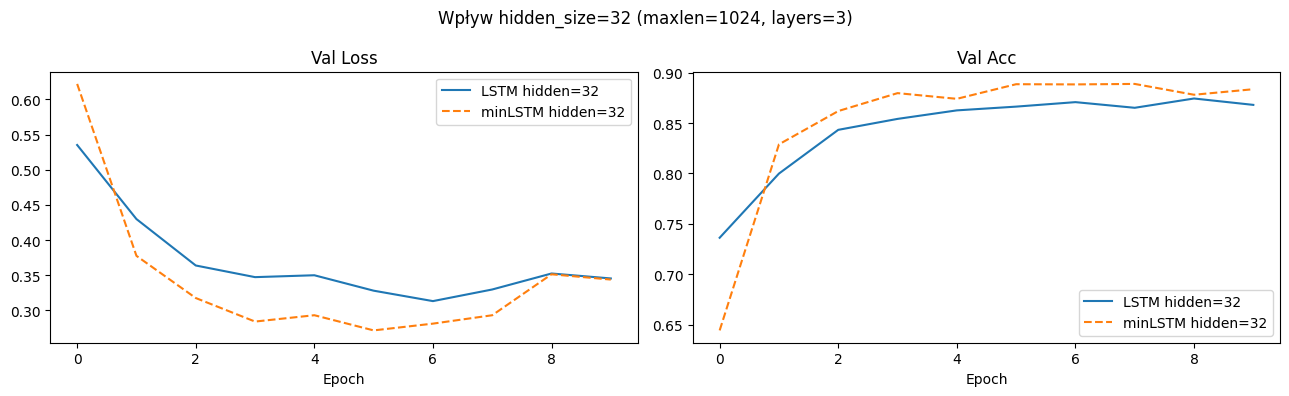

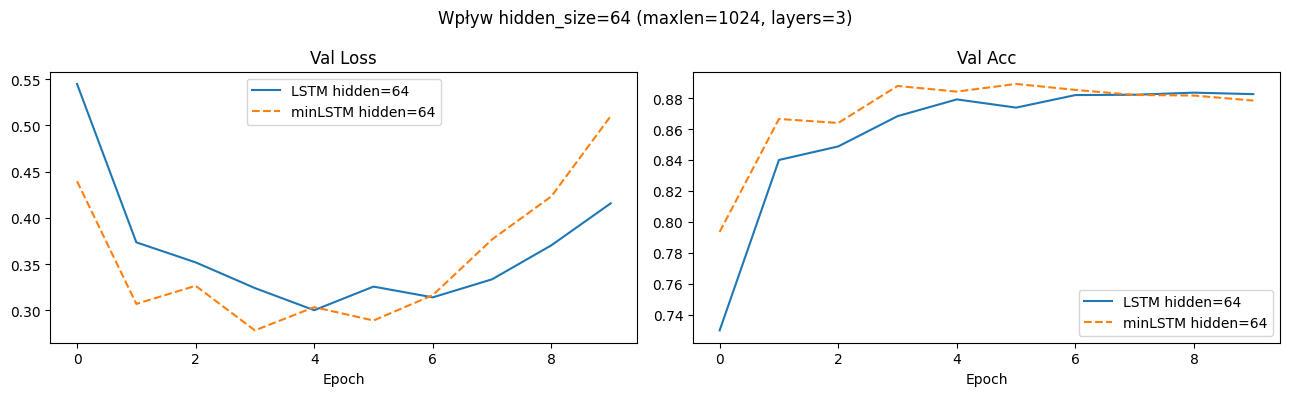

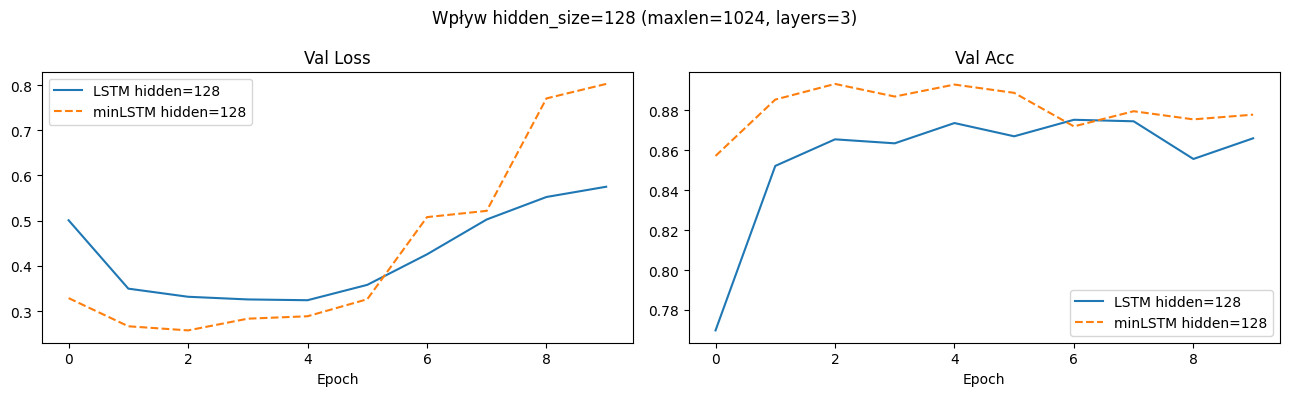

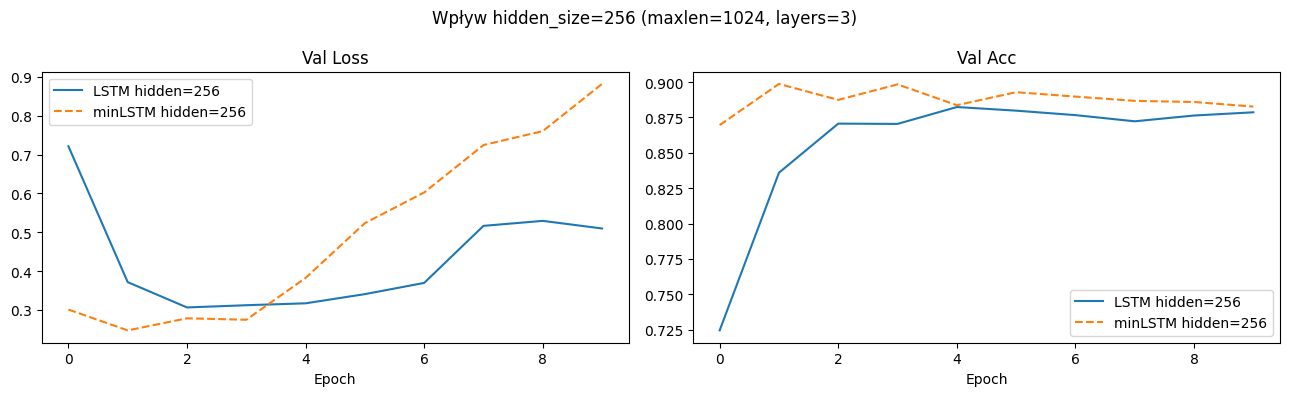

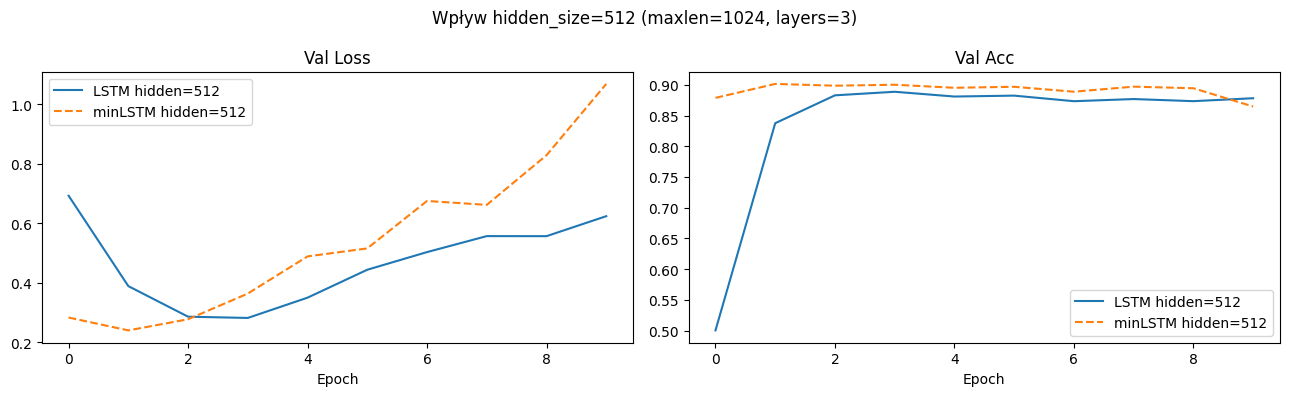


Model                  hidden   Best Acc    Best F1   Czas (s)
--------------------------------------------------------------
LSTM                       32     0.8743     0.8742     1037.8
minLSTM                    32     0.8888     0.8888      138.3

LSTM                       64     0.8835     0.8834     1029.2
minLSTM                    64     0.8892     0.8891      216.4

LSTM                      128     0.8753     0.8753     1052.7
minLSTM                   128     0.8933     0.8932      373.0

LSTM                      256     0.8824     0.8822     1235.9
minLSTM                   256     0.8987     0.8986      751.5

LSTM                      512     0.8886     0.8886     1369.0
minLSTM                   512     0.9014     0.9014     1748.5



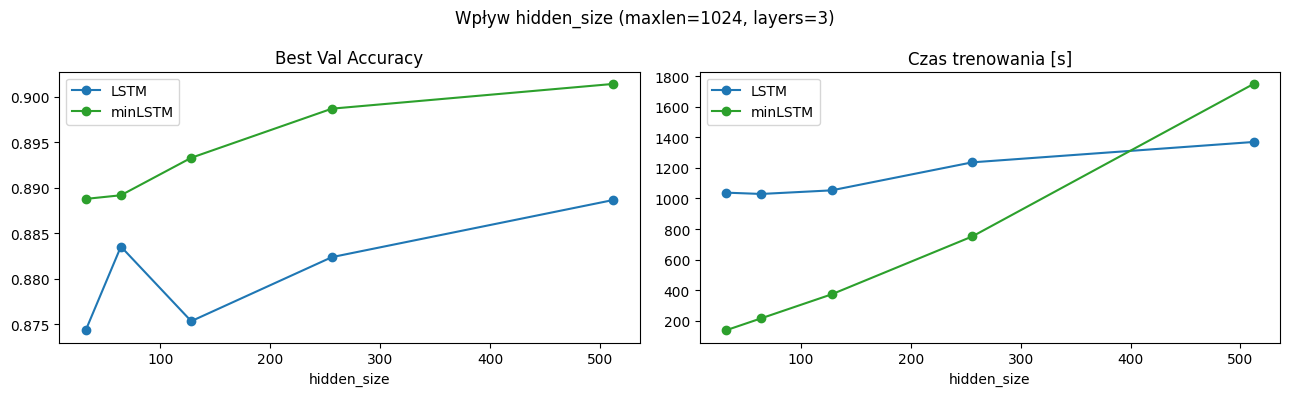

In [10]:
HIDDEN_SIZES   = [32, 64, 128, 256, 512]
MAXLEN_HIDDEN  = 1024
LAYERS_HIDDEN  = 3

train_h, test_h = get_imdb_dataloaders(MAXLEN_HIDDEN)

results_hidden = {}

for hs in HIDDEN_SIZES:
    res = run_experiment(
        f'minLSTM hidden={hs}',
        MinLSTMNet(VOCAB_SIZE, hs, LAYERS_HIDDEN, 2),
        train_h, test_h, EPOCHS, 2, DEVICE
    )
    results_hidden[('minLSTM', hs)] = res

    res = run_experiment(
        f'LSTM hidden={hs}',
        LSTMNet(VOCAB_SIZE, hs, LAYERS_HIDDEN, 2),
        train_h, test_h, EPOCHS, 2, DEVICE
    )
    results_hidden[('LSTM', hs)] = res

# ── Krzywe uczenia per hidden_size ────────────────────────────────────────────
for hs in HIDDEN_SIZES:
    plot_history(
        [results_hidden[('LSTM', hs)], results_hidden[('minLSTM', hs)]],
        f'Wpływ hidden_size={hs} (maxlen={MAXLEN_HIDDEN}, layers={LAYERS_HIDDEN})'
    )

# ── Tabela zbiorcza ────────────────────────────────────────────────────────────
print(f"\n{'Model':<20} {'hidden':>8} {'Best Acc':>10} {'Best F1':>10} {'Czas (s)':>10}")
print("-" * 62)
for hs in HIDDEN_SIZES:
    for model_name in ['LSTM', 'minLSTM']:
        res = results_hidden[(model_name, hs)]
        print(f"{model_name:<20} {hs:>8} {res['best_acc']:>10.4f} {res['best_f1']:>10.4f} {res['time_s']:>10.1f}")
    print()

# ── Zbiorczy wykres accuracy i czas vs hidden_size ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Wpływ hidden_size (maxlen={MAXLEN_HIDDEN}, layers={LAYERS_HIDDEN})')

for model_name, color in [('LSTM', 'tab:blue'), ('minLSTM', 'tab:green')]:
    accs  = [results_hidden[(model_name, hs)]['best_acc'] for hs in HIDDEN_SIZES]
    times = [results_hidden[(model_name, hs)]['time_s']   for hs in HIDDEN_SIZES]
    axes[0].plot(HIDDEN_SIZES, accs,  marker='o', color=color, label=model_name)
    axes[1].plot(HIDDEN_SIZES, times, marker='o', color=color, label=model_name)

axes[0].set_title('Best Val Accuracy'); axes[0].set_xlabel('hidden_size'); axes[0].legend()
axes[1].set_title('Czas trenowania [s]'); axes[1].set_xlabel('hidden_size'); axes[1].legend()
plt.tight_layout()
plt.show()


# 10. Wpływ lr na minLSTM



  minLSTM lr=1e-04
  Epoch 1/10 | Train Loss: 0.6871 Acc: 0.5453 | Val Loss: 0.6811 Acc: 0.5572 F1: 0.4722
  Epoch 2/10 | Train Loss: 0.6516 Acc: 0.6102 | Val Loss: 0.6331 Acc: 0.6326 F1: 0.6217
  Epoch 3/10 | Train Loss: 0.5961 Acc: 0.6724 | Val Loss: 0.5731 Acc: 0.6951 F1: 0.6930
  Epoch 4/10 | Train Loss: 0.5261 Acc: 0.7373 | Val Loss: 0.5021 Acc: 0.7533 F1: 0.7509
  Epoch 5/10 | Train Loss: 0.4413 Acc: 0.7940 | Val Loss: 0.4239 Acc: 0.8011 F1: 0.8006
  Epoch 6/10 | Train Loss: 0.3862 Acc: 0.8251 | Val Loss: 0.3826 Acc: 0.8250 F1: 0.8249
  Epoch 7/10 | Train Loss: 0.3484 Acc: 0.8459 | Val Loss: 0.3760 Acc: 0.8288 F1: 0.8277
  Epoch 8/10 | Train Loss: 0.3223 Acc: 0.8606 | Val Loss: 0.3418 Acc: 0.8474 F1: 0.8473
  Epoch 9/10 | Train Loss: 0.3028 Acc: 0.8695 | Val Loss: 0.3289 Acc: 0.8550 F1: 0.8550
  Epoch 10/10 | Train Loss: 0.2873 Acc: 0.8774 | Val Loss: 0.3301 Acc: 0.8557 F1: 0.8554
  → Czas: 2110.9s | Best Acc: 0.8557 | Best F1: 0.8554

  LSTM lr=1e-04
  Epoch 1/10 | Train Loss: 

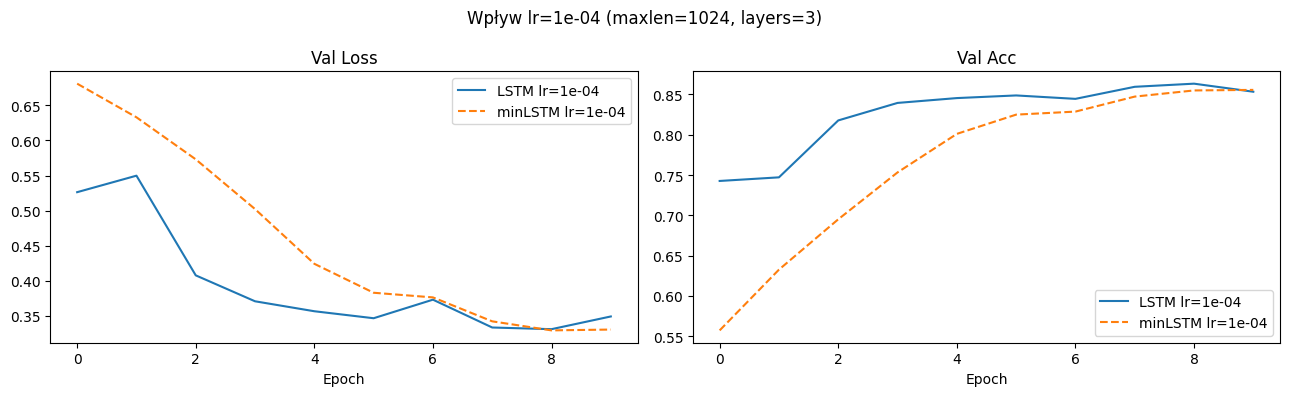

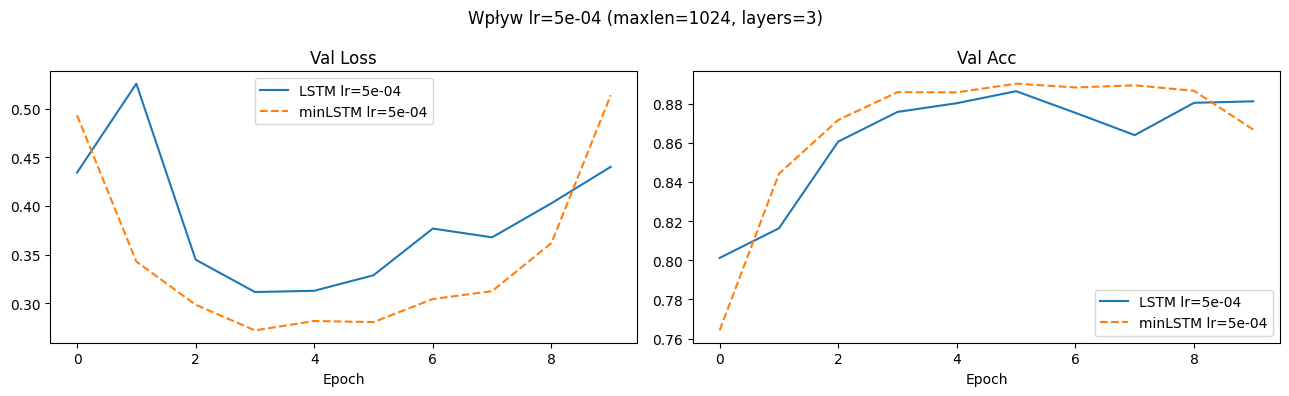

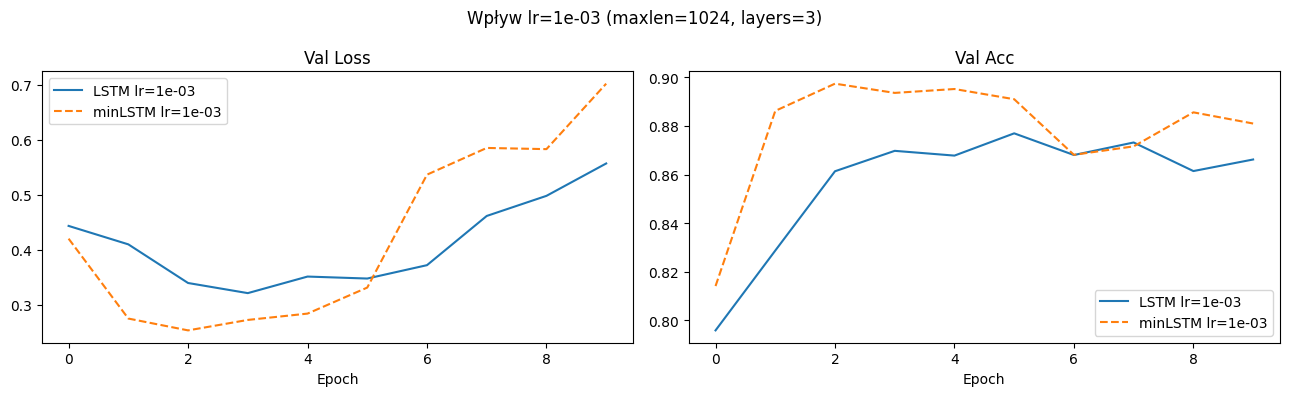

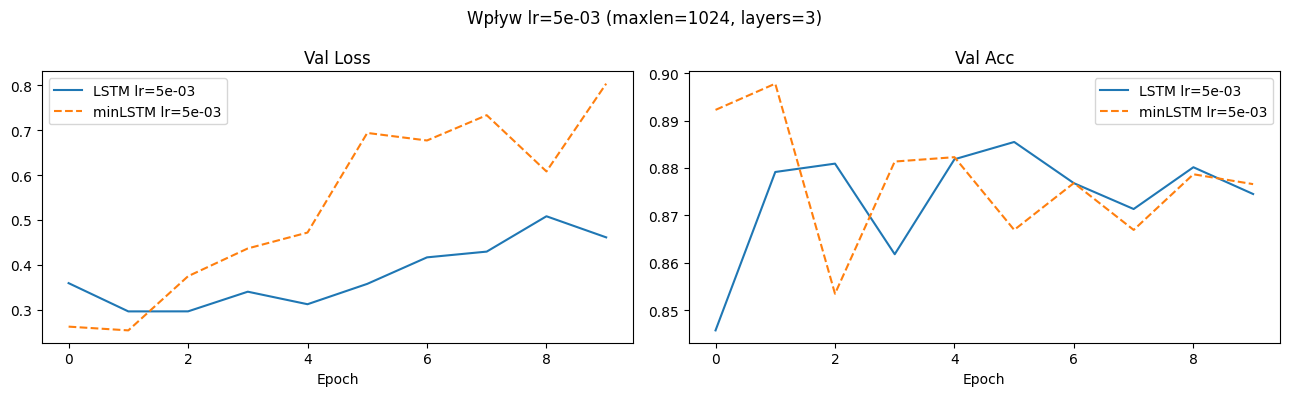

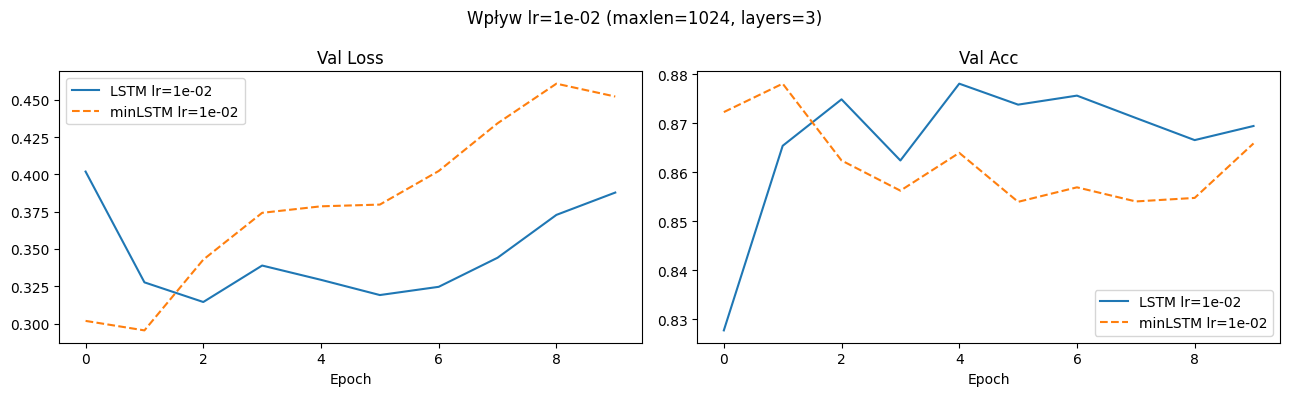


Model                        LR   Best Acc    Best F1   Best Epoch   Czas (s)
----------------------------------------------------------------------------
LSTM                      1e-04     0.8634     0.8633            9     1061.8
minLSTM                   1e-04     0.8557     0.8554           10     2110.9

LSTM                      5e-04     0.8863     0.8863            6     1065.8
minLSTM                   5e-04     0.8901     0.8901            6     1898.7

LSTM                      1e-03     0.8770     0.8770            6     1065.7
minLSTM                   1e-03     0.8974     0.8974            3     1666.6

LSTM                      5e-03     0.8855     0.8854            6     1069.2
minLSTM                   5e-03     0.8978     0.8977            2     1755.1

LSTM                      1e-02     0.8781     0.8781            5     1074.4
minLSTM                   1e-02     0.8781     0.8781            2     2068.6



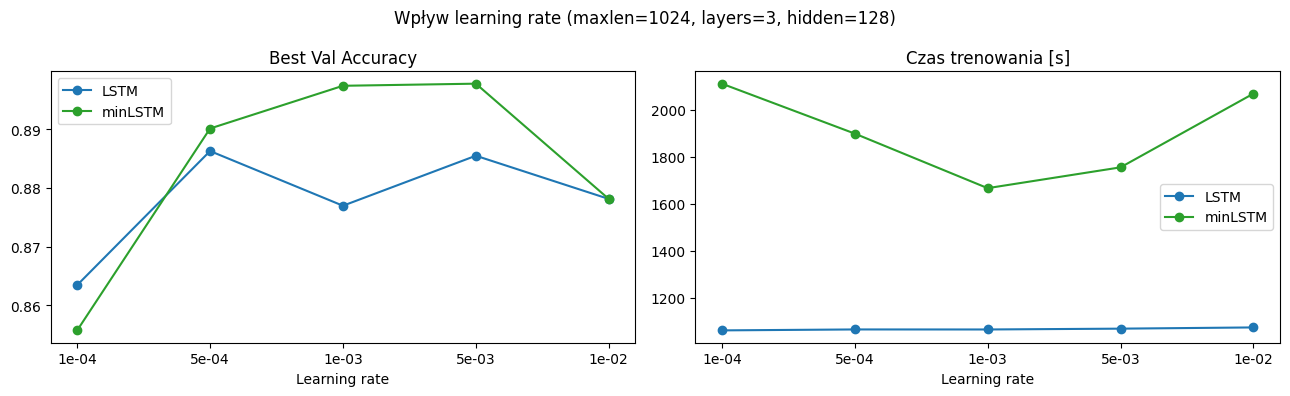

In [11]:
LEARNING_RATES = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
MAXLEN_LR      = 1024
LAYERS_LR      = 3

train_lr, test_lr = get_imdb_dataloaders(MAXLEN_LR)

results_lr = {}  # klucz: (model, lr)

for lr in LEARNING_RATES:
    res = run_experiment(
        f'minLSTM lr={lr:.0e}',
        MinLSTMNet(VOCAB_SIZE, HIDDEN, LAYERS_LR, 2),
        train_lr, test_lr, EPOCHS, 2, DEVICE,
        lr=lr
    )
    results_lr[('minLSTM', lr)] = res

    res = run_experiment(
        f'LSTM lr={lr:.0e}',
        LSTMNet(VOCAB_SIZE, HIDDEN, LAYERS_LR, 2),
        train_lr, test_lr, EPOCHS, 2, DEVICE,
        lr=lr
    )
    results_lr[('LSTM', lr)] = res

# ── Krzywe uczenia per LR ─────────────────────────────────────────────────────
for lr in LEARNING_RATES:
    plot_history(
        [results_lr[('LSTM', lr)], results_lr[('minLSTM', lr)]],
        f'Wpływ lr={lr:.0e} (maxlen={MAXLEN_LR}, layers={LAYERS_LR})'
    )

# ── Tabela zbiorcza ────────────────────────────────────────────────────────────
print(f"\n{'Model':<20} {'LR':>10} {'Best Acc':>10} {'Best F1':>10} {'Best Epoch':>12} {'Czas (s)':>10}")
print("-" * 76)
for lr in LEARNING_RATES:
    for model_name in ['LSTM', 'minLSTM']:
        res     = results_lr[(model_name, lr)]
        best_ep = res['history']['val_acc'].index(max(res['history']['val_acc'])) + 1
        print(f"{model_name:<20} {lr:>10.0e} {res['best_acc']:>10.4f} {res['best_f1']:>10.4f} {best_ep:>12} {res['time_s']:>10.1f}")
    print()

# ── Zbiorczy wykres accuracy i czas vs LR ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Wpływ learning rate (maxlen={MAXLEN_LR}, layers={LAYERS_LR}, hidden={HIDDEN})')
lr_labels = [f'{lr:.0e}' for lr in LEARNING_RATES]

for model_name, color in [('LSTM', 'tab:blue'), ('minLSTM', 'tab:green')]:
    accs  = [results_lr[(model_name, lr)]['best_acc'] for lr in LEARNING_RATES]
    times = [results_lr[(model_name, lr)]['time_s']   for lr in LEARNING_RATES]
    axes[0].plot(lr_labels, accs,  marker='o', color=color, label=model_name)
    axes[1].plot(lr_labels, times, marker='o', color=color, label=model_name)

axes[0].set_title('Best Val Accuracy'); axes[0].set_xlabel('Learning rate'); axes[0].legend()
axes[1].set_title('Czas trenowania [s]'); axes[1].set_xlabel('Learning rate'); axes[1].legend()
plt.tight_layout()
plt.show()
